In [2]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from string import ascii_lowercase

import torch
# import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
import torchvision.utils as vutils
from torch.utils.data import Dataset, DataLoader

In [ ]:
BATCH_SIZE = 128
RATIO_VALIDATION = 0.25
IMG_SIZE = 28
WORKERS = 4

LATENT_DIM = 100
SIZE_GENERATOR_FEATURES = 28
SIZE_DISCRIMINATOR_FEATURES = 28
NUM_CHANNELS = 1
NUM_EPOCHS = 500

LEARNING_RATE = 0.0002
BETA1 = 0.5

transform = transforms.Compose(
    [
        transforms.ToTensor(),  # Convierte (H, W, 1) a (1, H, W)
        transforms.Normalize((0.5,), (0.5,)),  # Normaliza a [-1, 1] para 1 canal
    ]
)

ngpus: int = torch.cuda.device_count()
device: torch.device = torch.device("cuda" if ngpus > 0 else "cpu")

SAVE_PATH = "../models/runs/dcgan/train"

while os.path.exists(SAVE_PATH):
    if not os.path.exists(SAVE_PATH):
        break

    if len(os.listdir(SAVE_PATH)) == 0:
        break

    last_char = SAVE_PATH[-1]
    if last_char.isdigit():
        SAVE_PATH = SAVE_PATH[:-1] + str(int(last_char) + 1)
    else:
        SAVE_PATH = SAVE_PATH + "2"

os.makedirs(SAVE_PATH, exist_ok=True)

## Creating custom dataset

In [13]:
class CustomDataset(Dataset):
    ALLOWED_EXTENSIONS: list[str] = [".jpg", ".jpeg", ".png"]

    def __init__(self, root: str, transform: transforms.Compose | None = None) -> None:
        if not os.path.exists(root):
            raise FileNotFoundError(f"Path {root} does not exist")

        self.root: Path = Path(root)
        self.transform = transform

        images_path = [
            list(self.root.rglob(f"*{ext}")) for ext in self.ALLOWED_EXTENSIONS
        ]

        self.imgs_path: list[Path] = [
            item for sublist in images_path for item in sublist
        ]

    def map_label(self, label: str, characters_lowercase: str = ascii_lowercase) -> int:
        label = label.lower().split(".")[0]
        label = label[
            0
        ]  # TODO: CHANGE THE WAY TO GET THE LABEL, THERE'S MUST BE A BETTER WAY

        return characters_lowercase.index(label)

    def __len__(self) -> int:
        return len(self.imgs)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        img_path = self.imgs_path[index]

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        img = img.astype(np.float32) / 255.0  # Normaliza a [0, 1]

        label = self.map_label(img_path.name)
        label = torch.tensor(label, dtype=torch.uint8)

        if self.transform:
            img = self.transform(img)
        else:
            img = torch.from_numpy(img).float()

        return img, label

    # DataLoader requires to have this property
    @property
    def imgs(self) -> list[Path]:
        return self.imgs_path


In [14]:
custom_dataset = CustomDataset(root="../data/processed/kaggle", transform=transform)
dataloader = DataLoader(
    custom_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=WORKERS
)

In [15]:
data_iter = iter(dataloader)
images, labels = next(data_iter)
print(f"images shape: {images.shape}")
print(f"labels shape: {labels.shape}")

images shape: torch.Size([128, 1, 28, 28])
labels shape: torch.Size([128])


## DCGAN

In [16]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

### Generator

In [17]:
class Generator(nn.Module):
    def __init__(self, ngpus: int):
        super(Generator, self).__init__()
        self.ngpu = ngpus
        self.main = nn.Sequential(
            # Paso 1: Proyectar el vector latente a 7x7x256 (como en Keras)
            nn.Linear(LATENT_DIM, 7*7*256, bias=False),
            nn.BatchNorm1d(7*7*256),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Redimensionar a (7, 7, 256)
            nn.Unflatten(1, (256, 7, 7)),  # (batch, 256, 7, 7)

            # Paso 2: ConvTranspose para 7x7x256 -> 7x7x128
            nn.ConvTranspose2d(256, 128, kernel_size=5, stride=1, padding=2, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # Paso 3: 7x7x128 -> 14x14x64
            nn.ConvTranspose2d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # Paso 4: 14x14x64 -> 28x28x32
            nn.ConvTranspose2d(64, 32, kernel_size=5, stride=2, padding=2, output_padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),

            # Paso 5: 28x28x32 -> 28x28x1 (usamos kernel_size=5 para mantener 28x28)
            nn.ConvTranspose2d(32, 1, kernel_size=5, stride=1, padding=2, bias=False),
            nn.Tanh()  # Normaliza a [-1, 1]
        )

    def forward(self, input):
        return self.main(input)


In [18]:
# Create the generator
netG = Generator(ngpus).to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpus > 1):
    netG = nn.DataParallel(netG, list(range(ngpus)))

# Apply the ``weights_init`` function to randomly initialize all weights
#  to ``mean=0``, ``stdev=0.02``.
netG.apply(weights_init)

# Print the model
print(netG)

Generator(
  (main): Sequential(
    (0): Linear(in_features=100, out_features=12544, bias=False)
    (1): BatchNorm1d(12544, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Unflatten(dim=1, unflattened_size=(256, 7, 7))
    (4): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2, inplace=True)
    (7): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): LeakyReLU(negative_slope=0.2, inplace=True)
    (10): ConvTranspose2d(64, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
    (11): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_

### Discriminator

In [19]:
class Discriminator(nn.Module):
    def __init__(self, ngpus: int):
        super(Discriminator, self).__init__()
        self.ngpu = ngpus
        self.main = nn.Sequential(
            # Capa 1: Conv2D(64, kernel_size=3, padding='same') -> MaxPool2D(2)
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),  # Reduce a 14x14
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # Capa 2: Conv2D(32, kernel_size=3) -> MaxPool2D(2)
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=0, bias=False),  # Padding 'valid' en Keras
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),  # Reduce a 6x6 (porque padding='valid' en Keras)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # Capa 3: Conv2D(16, kernel_size=3) -> MaxPool2D(2)
            nn.Conv2d(32, 16, kernel_size=3, stride=1, padding=0, bias=False),  # Padding 'valid'
            nn.BatchNorm2d(16),
            nn.MaxPool2d(2),  # Reduce a 2x2
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # Flatten + Dense(128)
            nn.Flatten(),
            nn.Linear(16 * 2 * 2, 128),  # 16 canales * 2x2 (salida de la última capa)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),

            # Salida: Dense(1, activation='sigmoid')
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)


In [20]:
# Create the Discriminator
netD = Discriminator(ngpus).to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpus > 1):
    netD = nn.DataParallel(netD, list(range(ngpus)))

# Apply the ``weights_init`` function to randomly initialize all weights
# like this: ``to mean=0, stdev=0.2``.
netD.apply(weights_init)

# Print the model
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Dropout(p=0.3, inplace=False)
    (5): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
    (9): Dropout(p=0.3, inplace=False)
    (10): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (11): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): LeakyReLU(negative_

In [21]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(BATCH_SIZE, LATENT_DIM, device=device)

# Establish convention for real and fake labels during training
real_label = 1.
fake_label = 0.

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))

### Training

In [25]:
# Training Loop

best_loss = float('inf')

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
# For each epoch
for epoch in range(NUM_EPOCHS):
    # For each batch in the dataloader
    for i, data in enumerate(dataloader, 0):
        ############################
        # (1) Update D network: maximize log(D(x)) +
        ###########################
        ## Train with all-real batch
        netD.zero_grad()
        # Format batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # Forward pass real batch through D
        output = netD(real_cpu).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, LATENT_DIM, device=device)
        # Generate fake image batch with G
        fake = netG(noise)
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the fake and the real batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        netG.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = netD(fake).view(-1)
        # Calculate G's loss based on this output
        errG = criterion(output, label)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print(
                f"[{epoch}/{NUM_EPOCHS}][{i}/{len(dataloader)}]\t" \
                f"Loss_G: {errG.item():.4f}\tLoss_D: {errD.item():.4f}\tD(x): {D_x:.4f}\tD(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}"
            )

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or (
            (epoch == NUM_EPOCHS - 1) and (i == len(dataloader) - 1)
        ):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

        # Find the best model
        total_loss = errD.item() + errG.item()

        # Save the best model
        if total_loss < best_loss:
            best_loss = total_loss
            best_model = {
                'epoch': epoch,
                'generator_state_dict': netG.state_dict(),
                'discriminator_state_dict': netD.state_dict(),
                'optimizerG_state_dict': optimizerG.state_dict(),
                'optimizerD_state_dict': optimizerD.state_dict(),
                'best_loss': best_loss,
            }

torch.save(
    best_model,
    os.path.join(SAVE_PATH, f"best_model_epoch{best_model['epoch']}.pth"),
)


Starting Training Loop...
[0/500][0/13]	Loss_G: 1.0949	Loss_D: 1.0819	D(x): 0.5791	D(G(z)): 0.3260 / 0.4123
[1/500][0/13]	Loss_G: 1.3515	Loss_D: 0.9488	D(x): 0.7273	D(G(z)): 0.3841 / 0.3262
[2/500][0/13]	Loss_G: 1.2578	Loss_D: 0.8955	D(x): 0.6714	D(G(z)): 0.3177 / 0.3627
[3/500][0/13]	Loss_G: 1.2489	Loss_D: 1.0156	D(x): 0.6379	D(G(z)): 0.3457 / 0.3607
[4/500][0/13]	Loss_G: 1.1970	Loss_D: 0.9559	D(x): 0.6577	D(G(z)): 0.3276 / 0.3605
[5/500][0/13]	Loss_G: 1.4471	Loss_D: 0.9071	D(x): 0.6421	D(G(z)): 0.2890 / 0.2986
[6/500][0/13]	Loss_G: 1.0558	Loss_D: 1.0397	D(x): 0.6672	D(G(z)): 0.3764 / 0.4104
[7/500][0/13]	Loss_G: 1.2977	Loss_D: 0.9059	D(x): 0.6989	D(G(z)): 0.3438 / 0.3509
[8/500][0/13]	Loss_G: 1.6505	Loss_D: 0.9560	D(x): 0.6991	D(G(z)): 0.3582 / 0.2637
[9/500][0/13]	Loss_G: 1.1861	Loss_D: 1.0542	D(x): 0.6462	D(G(z)): 0.3540 / 0.3897
[10/500][0/13]	Loss_G: 1.4305	Loss_D: 0.9654	D(x): 0.6197	D(G(z)): 0.2909 / 0.3268
[11/500][0/13]	Loss_G: 1.1062	Loss_D: 0.9347	D(x): 0.6595	D(G(z)): 0.31

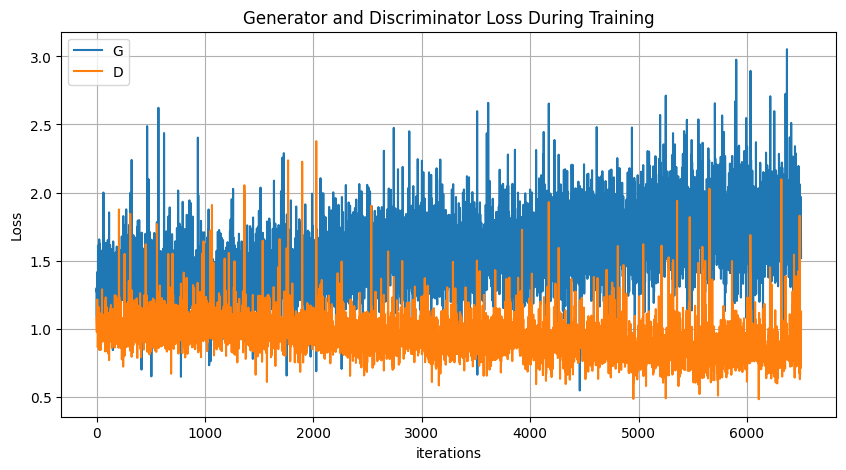

In [26]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

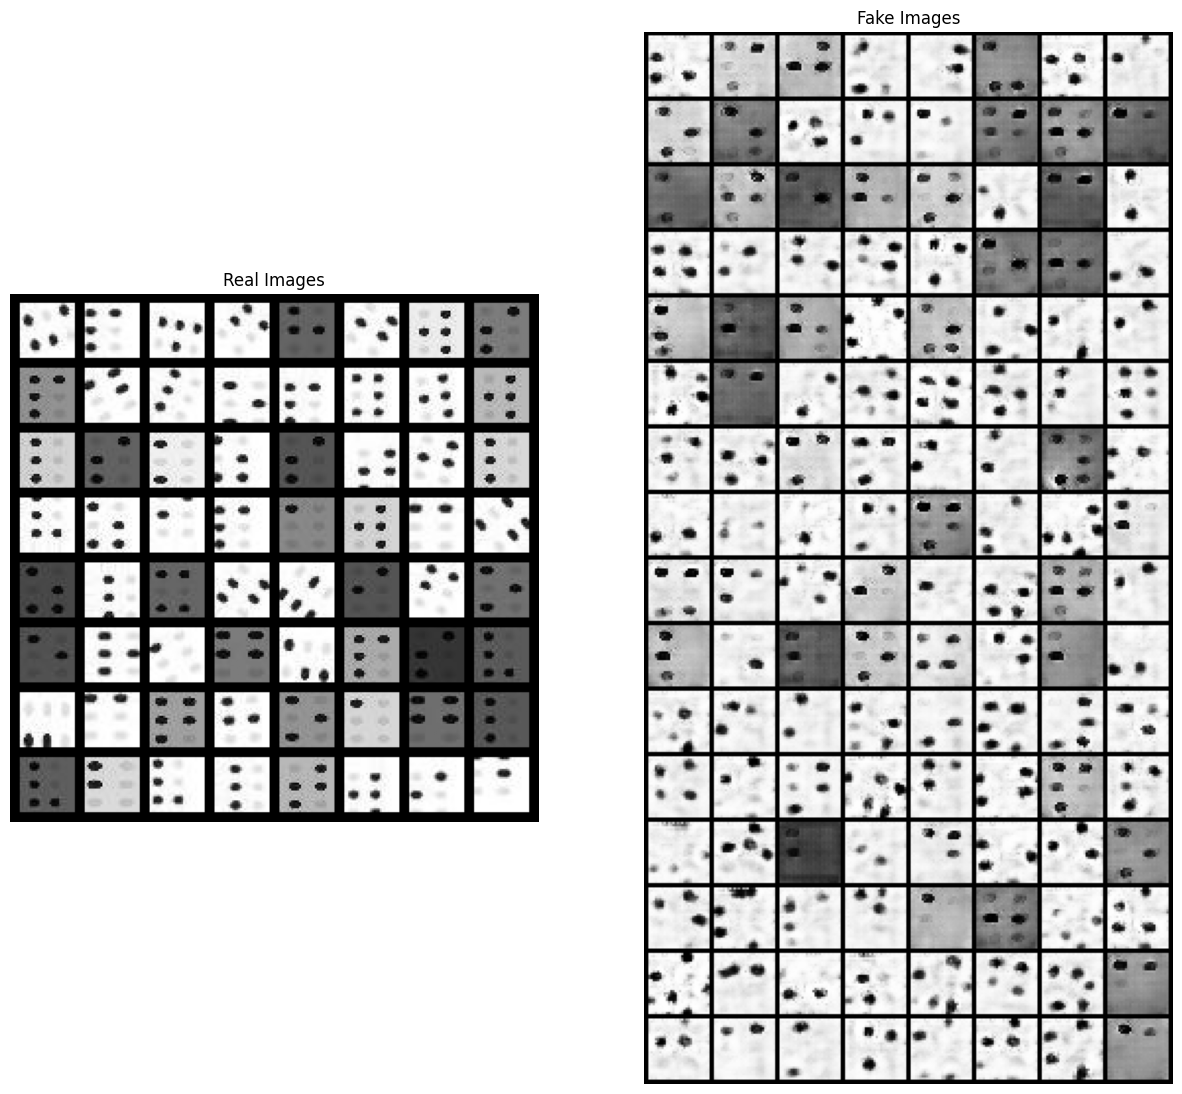

In [27]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

# Plot the real images
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

# Plot the fake images from the last epoch
plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()

### Cargar modelo

In [28]:
checkpoint = torch.load(os.path.join(SAVE_PATH, 'best_model_epoch342.pth'), map_location=device)
netG.load_state_dict(checkpoint['generator_state_dict'])
netD.load_state_dict(checkpoint['discriminator_state_dict'])
optimizerG.load_state_dict(checkpoint['optimizerG_state_dict'])
optimizerD.load_state_dict(checkpoint['optimizerD_state_dict'])

print(f"Cargado modelo de la época {checkpoint['epoch']}, con pérdida {checkpoint['best_loss']:.4f}")

Cargado modelo de la época 342, con pérdida 1.4114
